In [129]:
import sys
sys.path.append('../../src/')
import TFIM_operators_from_states as op
from project_imports import *

In [130]:
import numpy as np

def uv_tfim(g, k):
    """
    Ground-state Bogoliubov coefficients (u_k, v_k)
    for 1D TFIM at field g.
    
    k : array (0 < k < pi)
    g : scalar or array broadcastable with k
    """
    eps = np.sqrt((g - np.cos(k))**2 + np.sin(k)**2)

    u = np.sqrt(0.5 * (1 + (g - np.cos(k)) / eps))
    v = np.sqrt(0.5 * (1 - (g - np.cos(k)) / eps))

    return u, v

def ab_tfim_u(alpha,beta,g,k):
    u_g,v_g = uv_tfim(g,k)
    u = alpha * u_g - 1j * beta * v_g
    #v = -1j * alpha * v_g + beta * u_g
    return u
def ab_tfim_v(alpha,beta,g,k):
    u_g,v_g = uv_tfim(g,k)
    #u = alpha * u_g - 1j * beta * v_g
    v = -1j * alpha * v_g + beta * u_g
    return v

def u0(alpha,beta,g,k):
    return array([ab_tfim_u(alpha,beta,g,ki) for ki in k])
def v0(alpha,beta,g,k):
    return array([ab_tfim_v(alpha,beta,g,ki) for ki in k])



In [131]:
L = 100 #System Size
k = array([pi/L*(1+2*i) for i in range(0,L//2)]) #Momenta Sectors

g=-0 #g that the state is in reference towards

#Storing weights as a tuple (alpha,beta)

weights = [(1,0),(0,1),(sqrt(1/2),sqrt(1/2))]
#alpha is the ground state amplitude, beta is the excited state
#Here, we pick the ground state
alpha,beta= weights[0]
u = u0(alpha,beta,g,k)
v = v0(alpha,beta,g,k)
#Must be in the state form [u,v,k] for op. module to work
state0= [u,v,k]
#For instance, we can set these up in the excited state
alpha,beta= weights[1]
u = u0(alpha,beta,g,k)
v = v0(alpha,beta,g,k)
state1= [u,v,k]
#Or, as as uperposition
alpha,beta= weights[-1]
u = u0(alpha,beta,g,k)
v = v0(alpha,beta,g,k)
state2= [u,v,k]


#Example
print("Ground State")
print(r"<X0X1>=", op.sx_correlation([0,1],state0))
print(r"<Z>=", op.sz_correlation([0],state0))
#Example
print("Excited State")
print(r"<X0X1>=", op.sx_correlation([0,1],state1))
print(r"<Z>=", op.sz_correlation([0],state1))
print("Super Position")
print(r"<X0X1>=", op.sx_correlation([0,1],state2))
print(r"<Z>=", op.sz_correlation([0],state2))


Ground State
<X0X1>= (1+0j)
<Z>= 0.0
Excited State
<X0X1>= (-1+0j)
<Z>= 0.0
Super Position
<X0X1>= 0.0
<Z>= 0.0


In [132]:
def g_f(t,args):
    gf= args
    return gf
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 500
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0
t_eval = np.linspace(0,2,50)
args = gf
ns =  [2,3,4,5,6,7,8,9,10,11]

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1


def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite all modes with k_index <= j

    for m in range(j+1):
        u[m] = ab_tfim_u(alpha, beta, gf, k[m])
        v[m] = ab_tfim_v(alpha, beta, gf, k[m])

    state0 = [u, v, k]
    
    #states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = array([2 *(op.Px_n(n,state0)) for n in ns])
    #results=[]
    
    for n in ns:
        pass
        #x = np.array([op.Px_n(n, s) for s in states])
        #results.append(np.max(x) - np.min(x))

    return results

# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)        # shape: (len(k), len(ns))


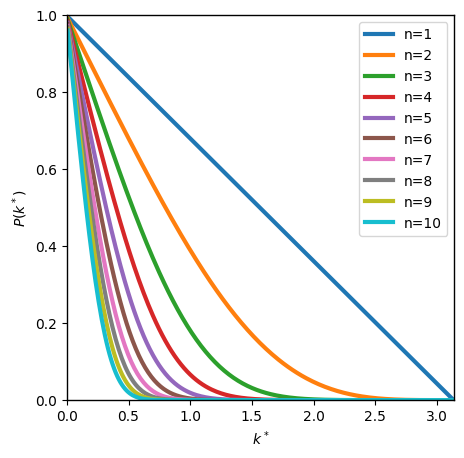

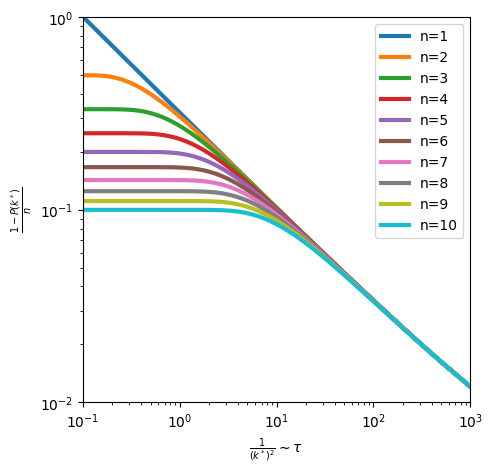

In [133]:
# ---- plot ----
fig, ax = plt.subplots(figsize=(5,5))

for i, n in enumerate(ns):
    ax.plot(k, out[:, i], lw=3, label=f"n={n-1}")

ax.set_xlim(0, np.pi)
ax.set_ylim(0,1)
ax.set_xlabel(r"$k^*$")
ax.set_ylabel(r"$P(k^*)$")
ax.legend()

# bold outline
for spine in ax.spines.values():
    spine.set_linewidth(1)

#ax.tick_params(width=2, length=6)

plt.show()


# ---- plot ----
fig, ax = plt.subplots(figsize=(5,5))

for i, n in enumerate(ns):
    ax.plot(1/k/k, (1-(out[:, i]))/(n-1), lw=3, label=f"n={n-1}")

ax.set_xlabel(r"$\frac{1}{(k^*)^2}\sim \tau$")
ax.set_ylabel(r"$\frac{1-P(k^*)}{n}$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10e-2,10e2)
ax.set_ylim(10e-3,1)

ax.legend()


plt.show()

In [134]:
def g_f(t,args):
    gf= args
    return gf
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 500
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0
t_eval = np.linspace(0,2,50)
args = gf
ns =  [2,3,4,5,6,7,8,9,10,11]

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1


def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite all modes with k_index <= j

    for m in range(j+1):
        u[m] = ab_tfim_u(alpha, beta, gf, k[m])
        v[m] = ab_tfim_v(alpha, beta, gf, k[m])

    state0 = [u, v, k]
    
    #states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = array([ 2*(op.Px_n(n,state0)) for n in ns])
    #results=[]
    
    for n in ns:
        pass
        #x = np.array([op.Px_n(n, s) for s in states])
        #results.append(np.max(x) - np.min(x))

    return results

# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)        # shape: (len(k), len(ns))


In [135]:
def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite ONLY mode j
    u[j] = ab_tfim_u(alpha, beta, gf, k[j])
    v[j] = ab_tfim_v(alpha, beta, gf, k[j])

    state0 = [u, v, k]

    # expectation values for all n
    results = np.array([ op.Pz_n(n, state0) for n in ns])

    return results


# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)   # shape: (len(k), len(ns))


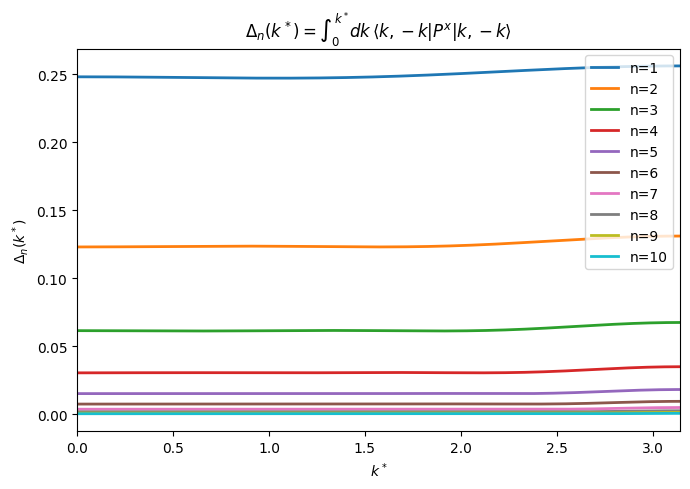

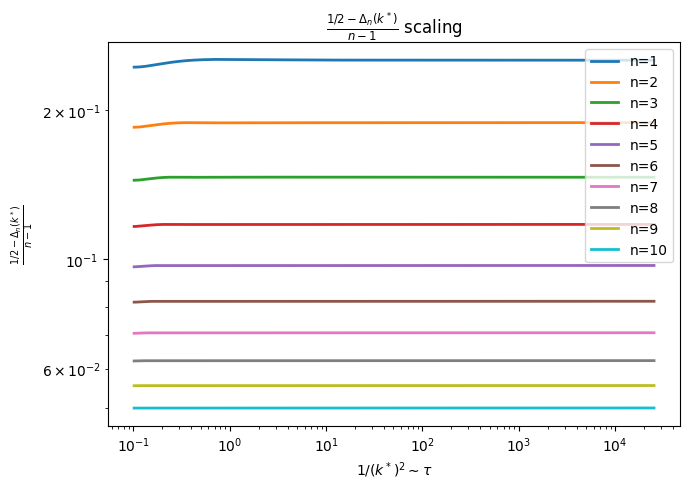

In [136]:
# ---- plot Δ_n(k*) ----
plt.figure(figsize=(7,5))

for i, n in enumerate(ns):
    plt.plot(k, out[:, i], lw=2, label=f"n={n-1}")

plt.xlim(0, np.pi)
plt.xlabel(r"$k^*$")
plt.ylabel(r"$\Delta_n(k^*)$")
plt.title(r"$\Delta_n(k^*)=\int_0^{k^*} dk\,\langle k,-k|P^x|k,-k\rangle$")
plt.legend()
plt.tight_layout()
plt.show()


# ---- plot scaling vs τ ~ 1/(k*)^2 ----
plt.figure(figsize=(7,5))

tau_eff = 1/(k**2)

for i, n in enumerate(ns):
    y = (0.5 - out[:, i])/(n-1)
    plt.plot(tau_eff, y, lw=2, label=f"n={n-1}")

plt.xlabel(r"$1/(k^*)^2 \sim \tau$")
plt.ylabel(r"$\frac{1/2-\Delta_n(k^*)}{n-1}$")
plt.title(r"$\frac{1/2-\Delta_n(k^*)}{n-1}$ scaling")
plt.legend()

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

In [137]:
def g_f(t,args):
    gf= args
    return gf
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
L = 500
k = array([pi/L*(1+2*i) for i in range(0,L//2)])
gf = 0
t_eval = np.linspace(0,2,50)
args = gf
ns =  [2,3,4,5,6,7,8,9,10,11,12,13,14]

# precompute ground state once
u0 = np.array([ab_tfim_u(1,0,gf,ki) for ki in k])
v0 = np.array([ab_tfim_v(1,0,gf,ki) for ki in k])

alpha = 0
beta  = 1


def compute_for_mode(j):

    u = u0.copy()
    v = v0.copy()

    # excite all modes with k_index <= j

    for m in range(j+1):
        u[m] = ab_tfim_u(alpha, beta, gf, k[m])
        v[m] = ab_tfim_v(alpha, beta, gf, k[m])

    state0 = [u, v, k]
    
    #states = nq.states(L, t_eval, g_f, args, state_0=state0)

    results = array([ (op.Px_n(n,state0)) for n in ns])
    #results=[]
    
    for n in ns:
        pass
        #x = np.array([op.Px_n(n, s) for s in states])
        #results.append(np.max(x) - np.min(x))

    return results

# parallel over k modes
out = Parallel(n_jobs=-1)(
    delayed(compute_for_mode)(j) for j in range(len(k))
)

out = np.array(out)        # shape: (len(k), len(ns))


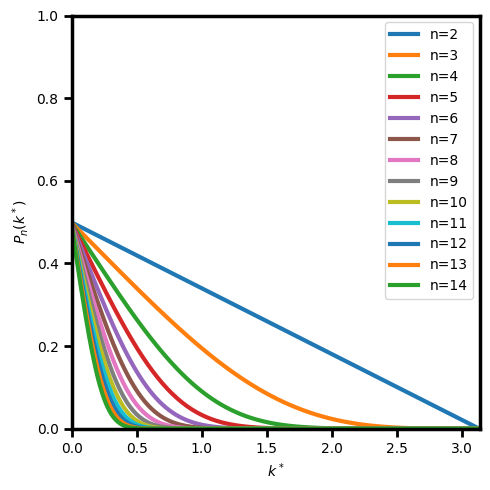

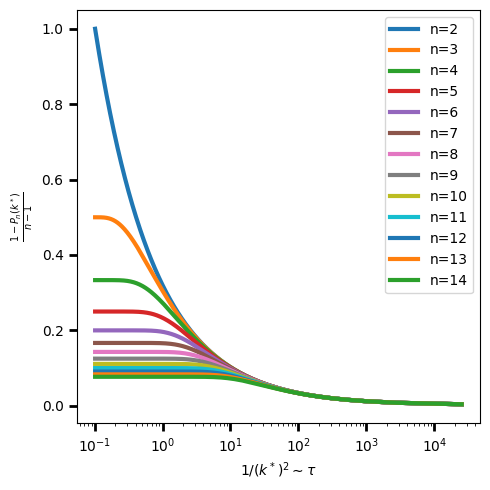

In [ ]:
# ---- plot P_n(k*) ----
fig, ax = plt.subplots(figsize=(5,5))

for i, n in enumerate(ns):
    ax.plot(k, out[:, i], lw=3, label=f"n={n}")

ax.set_xlim(0, np.pi)
ax.set_ylim(0,1)

ax.set_xlabel(r"$k^*$")
ax.set_ylabel(r"$P_n(k^*)$")

ax.legend()

# bold frame
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

ax.tick_params(width=2, length=6)

plt.tight_layout()
plt.show()


# ---- scaling plot ----
fig, ax = plt.subplots(figsize=(5,5))

tau_eff = 1/(k**2)

for i, n in enumerate(ns):

    y = (1 - 2*out[:, i])/(n-1)
    ax.plot(tau_eff, abs(y), lw=3, label=f"n={n}")

ax.set_xscale("log")

ax.set_xlabel(r"$1/(k^*)^2 \sim \tau$")
ax.set_ylabel(r"$\frac{1-P_n(k^*)}{n-1}$")

ax.legend()



ax.tick_params(width=2, length=6)

plt.tight_layout()
plt.show()

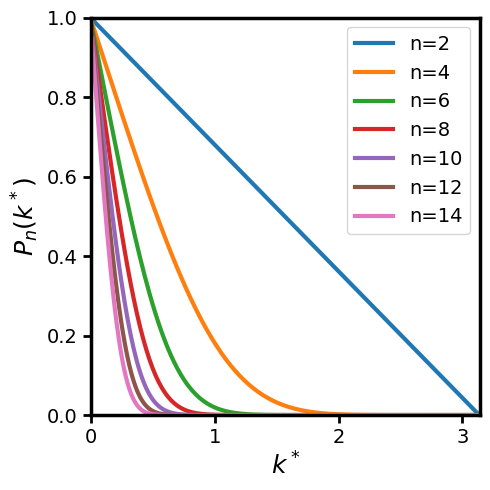

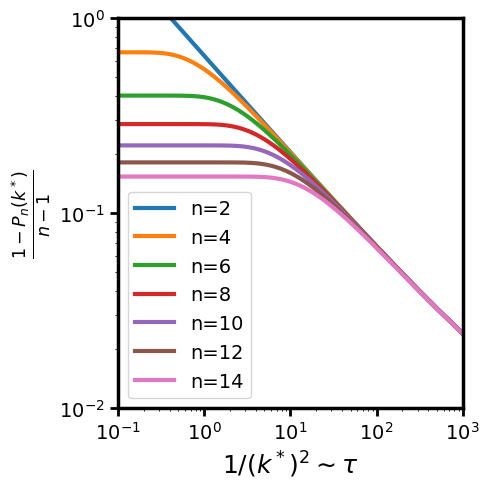

In [150]:
# ---------- style controls ----------
LW        = 3
BORDER_LW = 2.5
TICK_W    = 2
TICK_L    = 6

FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 14

FIG_W = 5
FIG_H = 5

N_SKIP = 2   # plot every N_SKIP-th n (2 = every other)

# ---------- P_n(k*) plot ----------
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for i, n in enumerate(ns[::N_SKIP]):

    idx = i * N_SKIP
    ax.plot(k, 2*out[:, idx], lw=LW, label=f"n={n}")

ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1)

ax.set_xlabel(r"$k^*$", fontsize=FS_LABEL)
ax.set_ylabel(r"$P_n(k^*)$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

# bold frame
for spine in ax.spines.values():
    spine.set_linewidth(BORDER_LW)

ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)

plt.tight_layout()
plt.show()


# ---------- scaling plot ----------
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

tau_eff = 1/(k**2)

for i, n in enumerate(ns[::N_SKIP]):

    idx = i * N_SKIP
    y = 2*(1 - 2*out[:, idx])/(n-1)

    ax.plot(tau_eff, np.abs(y), lw=LW, label=f"n={n}")

ax.set_xscale("log")

ax.set_xlabel(r"$1/(k^*)^2 \sim \tau$", fontsize=FS_LABEL)
ax.set_ylabel(r"$\frac{1-P_n(k^*)}{n-1}$", fontsize=FS_LABEL)
ax.set_xlim(10e-2,10e2)
ax.legend(fontsize=FS_LEGEND)
ax.loglog()
ax.set_ylim(10e-3,1)

for spine in ax.spines.values():
    spine.set_linewidth(BORDER_LW)

ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)

plt.tight_layout()
plt.show()

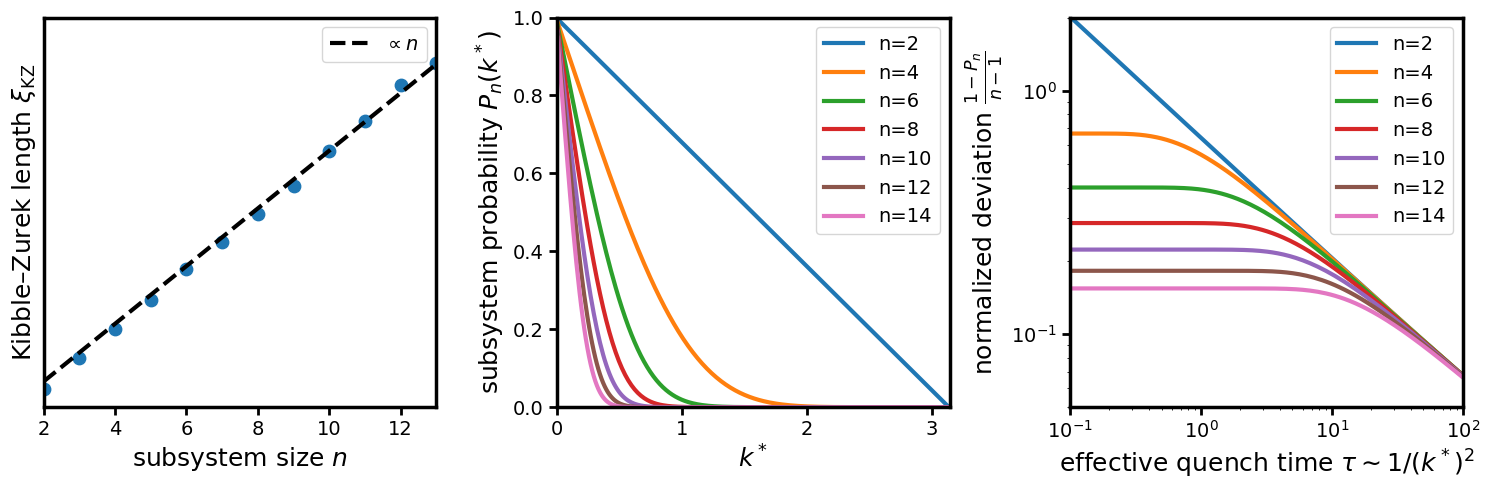

In [160]:
# ---------- style controls ----------
LW        = 3
BORDER_LW = 2.5
TICK_W    = 2
TICK_L    = 6

FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 14

FIG_W = 15
FIG_H = 5

N_SKIP = 2   # plot every other n

ns = np.array(ns)

# ---------- figure ----------
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H))

# -------------------------------------------------
# (1) KZ length vs n
# -------------------------------------------------
ax = axes[0]

ax.scatter(ns[1:]-1, np.sqrt(peak_tau[1:]), s=80)

ax.plot(ns, ns/2.7, "--k", lw=LW, label=r"$\propto n$")

ax.set_xlim(2, 13)

ax.set_xlabel(r"subsystem size $n$", fontsize=FS_LABEL)
ax.set_ylabel(r"Kibble–Zurek length $\xi_{\mathrm{KZ}}$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

# hide y ticks if desired
ax.set_yticks([])
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# -------------------------------------------------
# (2) P_n(k*)
# -------------------------------------------------
ax = axes[1]

for i, n in enumerate(ns[::N_SKIP]):
    idx = i * N_SKIP
    ax.plot(k, 2*out[:, idx], lw=LW, label=f"n={n}")

ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1)

ax.set_xlabel(r"$k^*$", fontsize=FS_LABEL)
ax.set_ylabel(r"subsystem probability $P_n(k^*)$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

# -------------------------------------------------
# (3) scaling collapse
# -------------------------------------------------
ax = axes[2]

tau_eff = 1/(k**2)

for i, n in enumerate(ns[::N_SKIP]):
    idx = i * N_SKIP
    y = 2*(1 - 2*out[:, idx])/(n-1)

    ax.plot(tau_eff, np.abs(y), lw=LW, label=f"n={n}")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e-1, 1e2)
ax.set_ylim(1e-1/2, 2)

ax.set_xlabel(r"effective quench time $\tau \sim 1/(k^*)^2$", fontsize=FS_LABEL)
ax.set_ylabel(r"normalized deviation $\frac{1-P_n}{n-1}$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

# -------------------------------------------------
# common styling
# -------------------------------------------------
for ax in axes:

    for spine in ax.spines.values():
        spine.set_linewidth(BORDER_LW)

    ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)

plt.tight_layout()
plt.show()

In [151]:
# ---- compute peaks ----
tau_eff = 1/(k**2)

peak_tau = []
peak_val = []

for i, n in enumerate(ns):

    y = (1 - 2*out[:, i])/(n-1)

    g2 = np.abs(np.gradient(np.gradient(y)))

    idx = np.argmax(g2)

    peak_tau.append(tau_eff[idx])
    peak_val.append(g2[idx])

    print(f"n={n}  peak τ = {tau_eff[idx]:.4e}   value = {g2[idx]:.4e}")

n=2  peak τ = 1.8503e+01   value = 2.7756e-17
n=3  peak τ = 4.0855e-01   value = 3.1997e-05
n=4  peak τ = 1.0821e+00   value = 4.5810e-05
n=5  peak τ = 1.9837e+00   value = 6.0409e-05
n=6  peak τ = 3.1979e+00   value = 7.5169e-05
n=7  peak τ = 4.7533e+00   value = 8.9971e-05
n=8  peak τ = 6.3820e+00   value = 1.0479e-04
n=9  peak τ = 8.3737e+00   value = 1.1961e-04
n=10  peak τ = 1.0550e+01   value = 1.3440e-04
n=11  peak τ = 1.3699e+01   value = 1.4924e-04
n=12  peak τ = 1.6654e+01   value = 1.6403e-04
n=13  peak τ = 2.0678e+01   value = 1.7860e-04
n=14  peak τ = 2.3260e+01   value = 1.9357e-04


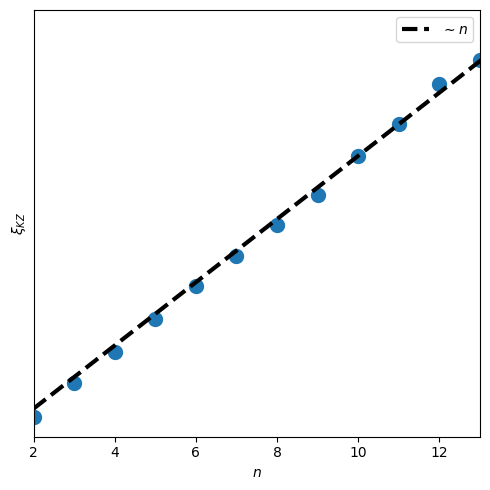

In [152]:
plt.figure(figsize=(5,5))
ns = np.array(ns)

plt.scatter(ns[1:]-1, np.sqrt(peak_tau[1:]), lw=5)
plt.plot(ns, ns/2.7, "--k", lw=3, label=r"$\sim n$")

plt.xlim(2,13)
plt.xlabel(r"$n$")
plt.ylabel(r"$ \xi_{KZ}$")
plt.legend()

ax = plt.gca()   # get current axis

ax.set_yticks([])
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.tight_layout()
plt.show()

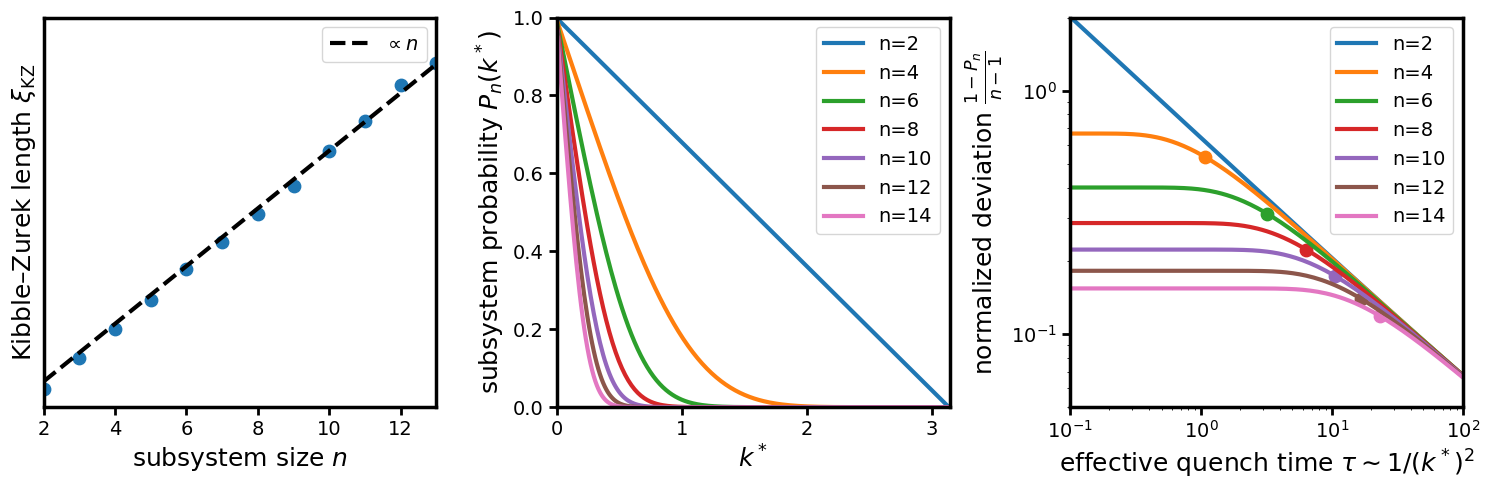

In [167]:
# ---------- style controls ----------
LW        = 3
BORDER_LW = 2.5
TICK_W    = 2
TICK_L    = 6

FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 14

FIG_W = 15
FIG_H = 5

N_SKIP = 2   # plot every other n

ns = np.array(ns)
xi_kz = np.sqrt(peak_tau)

# ---------- figure ----------
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H))

# -------------------------------------------------
# (1) KZ length vs n
# -------------------------------------------------
ax = axes[0]

ax.scatter(ns[1:]-1, xi_kz[1:], s=80)

ax.plot(ns, ns/2.7, "--k", lw=LW, label=r"$\propto n$")

ax.set_xlim(2, 13)

ax.set_xlabel(r"subsystem size $n$", fontsize=FS_LABEL)
ax.set_ylabel(r"Kibble–Zurek length $\xi_{\mathrm{KZ}}$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

ax.set_yticks([])
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# -------------------------------------------------
# (2) P_n(k*)
# -------------------------------------------------
ax = axes[1]

for i, n in enumerate(ns[::N_SKIP]):
    idx = i * N_SKIP
    ax.plot(k, 2*out[:, idx], lw=LW, label=f"n={n}")

ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1)

ax.set_xlabel(r"$k^*$", fontsize=FS_LABEL)
ax.set_ylabel(r"subsystem probability $P_n(k^*)$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

# -------------------------------------------------
# (3) scaling collapse
# -------------------------------------------------
ax = axes[2]

tau_eff = 1/(k**2)

for i, n in enumerate(ns[::N_SKIP]):
    idx = i * N_SKIP
    y = 2*(1 - 2*out[:, idx])/(n-1)

    ax.plot(tau_eff, np.abs(y), lw=LW, label=f"n={n}")

    # mark point from panel (1)
    tau_mark = xi_kz[idx]**2
    y_mark   = 2*(1 - 2*out[np.argmin(np.abs(tau_eff - tau_mark)), idx])/(n-1)
    if n ==2:
        ax.scatter(-100,-100)
    else:
        ax.scatter(tau_mark, np.abs(y_mark), s=80)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e-1, 1e2)
ax.set_ylim(1e-1/2, 2)

ax.set_xlabel(r"effective quench time $\tau \sim 1/(k^*)^2$", fontsize=FS_LABEL)
ax.set_ylabel(r"normalized deviation $\frac{1-P_n}{n-1}$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

# -------------------------------------------------
# common styling
# -------------------------------------------------
for ax in axes:

    for spine in ax.spines.values():
        spine.set_linewidth(BORDER_LW)

    ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)

plt.tight_layout()
plt.show()

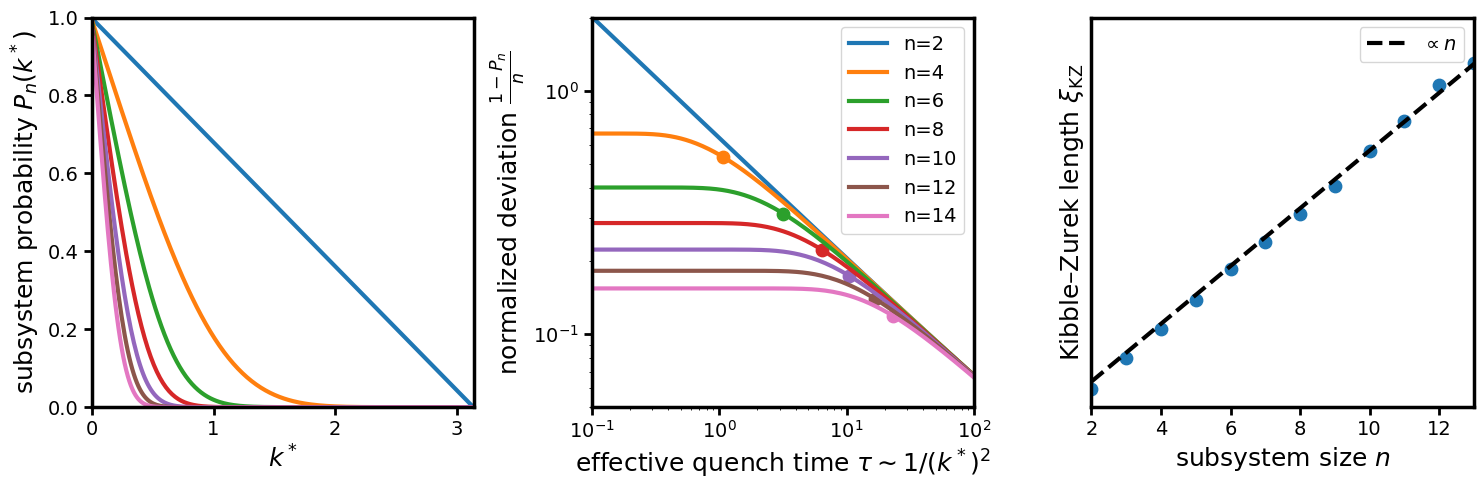

In [172]:
# ---------- style controls ----------
LW        = 3
BORDER_LW = 2.5
TICK_W    = 2
TICK_L    = 6

FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 14

FIG_W = 15
FIG_H = 5

N_SKIP = 2   # plot every other n

ns = np.array(ns)
xi_kz = np.sqrt(peak_tau)

# ---------- figure ----------
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H))

# -------------------------------------------------
# (1) P_n(k*)
# -------------------------------------------------
ax = axes[0]

for i, n in enumerate(ns[::N_SKIP]):
    idx = i * N_SKIP
    ax.plot(k, 2*out[:, idx], lw=LW, label=f"n={n}")

ax.set_xlim(0, np.pi)
ax.set_ylim(0, 1)

ax.set_xlabel(r"$k^*$", fontsize=FS_LABEL)
ax.set_ylabel(r"subsystem probability $P_n(k^*)$", fontsize=FS_LABEL)

#ax.legend(fontsize=FS_LEGEND)

# -------------------------------------------------
# (2) scaling collapse
# -------------------------------------------------
ax = axes[1]

tau_eff = 1/(k**2)

for i, n in enumerate(ns[::N_SKIP]):

    idx = i * N_SKIP
    y = 2*(1 - 2*out[:, idx])/(n-1)

    line, = ax.plot(tau_eff, np.abs(y), lw=LW, label=f"n={n}")

    # mark KZ point except n=2
    if n != 2:
        tau_mark = xi_kz[idx]**2
        y_mark   = 2*(1 - 2*out[np.argmin(np.abs(tau_eff - tau_mark)), idx])/(n-1)

        ax.scatter(tau_mark, np.abs(y_mark), s=80, color=line.get_color())

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e-1, 1e2)
ax.set_ylim(1e-1/2, 2)

ax.set_xlabel(r"effective quench time $\tau \sim 1/(k^*)^2$", fontsize=FS_LABEL)
ax.set_ylabel(r"normalized deviation $\frac{1-P_n}{n}$", fontsize=FS_LABEL)

#
ax.legend(fontsize=FS_LEGEND)

# -------------------------------------------------
# (3) KZ length vs n
# -------------------------------------------------
ax = axes[2]

ax.scatter(ns[1:]-1, xi_kz[1:], s=80)

ax.plot(ns, ns/2.7, "--k", lw=LW, label=r"$\propto n$")

ax.set_xlim(2, 13)

ax.set_xlabel(r"subsystem size $n$", fontsize=FS_LABEL)
ax.set_ylabel(r"Kibble–Zurek length $\xi_{\mathrm{KZ}}$", fontsize=FS_LABEL)

ax.legend(fontsize=FS_LEGEND)

ax.set_yticks([])
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# -------------------------------------------------
# common styling
# -------------------------------------------------
for ax in axes:

    for spine in ax.spines.values():
        spine.set_linewidth(BORDER_LW)

    ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)

plt.tight_layout()
plt.show()